# Black Jack V1

This bit uses First-visit MC policy to estimate $V \approx v_\pi$  

__Algo:__  
* I use $\epsilon-\text{greedy}$
* state $\in$ {dealer card, count, usable ace}
* action $\in$ {hit, stick}
* Infinite deck is assume

_process:__  
1. two cards to dealer (1 recorded as card up) 
2. two cards to player (ignore card up, not relevent) 
3. If player count <= 11 hit. 
4. Play:
   1. Given state take $\epsilon - \text{greedy action}$ 
   2. Continue to action is stick or bust 
   3. Update $v_\pi$ and $q_\pi$

## Updating $\pi$ and $q_\pi(s,a)$  

Run a simulation to get the following:  
1. final state: (dealer show, count, usable ace) e.g., (4, 22, 0)
2. final reward $\in (-1, 0, 1)$ , e.g.,  -1
3. Final Hand in order, e.g. [9, 1, 10, 2]
   
Evaluate backwards: $G = \gamma G + R_{t+1}$  

Process:  given a final hand ($hand$) for $len(hand) - 2$:  
Initialize: $G = 0, \gamma = 0.9$  
1. State: (4, 20, 0), action = "hit", R = -1
   * $G = \gamma(G) + -1 = 0 - 1 = -1$ 
   * increment $n_{q_\pi}((4,20,0)$ by 1 
   * Update $q_\pi((4,20,0), \text{hit}) = (q_\pi(4,20,0), \text{hit} + G) / n $
   * Update policy $\pi(a|(4,20,0)):
     * Let default value of policy be 0 (for early runs where it is not sampled)  
     * $\pi(a|(4,20,0)) = \arg\max_a(q_\pi(s = (4,20,0), A = a)$
     * set $q_\pi((4,20,0), \text{hit}) = \frac{q_\pi((4,20,0), \text{hit}) + G}{n} $
2. State: (4, 10, 1), action = "hit", R = 0 
   * $G = \gamma(G) + 0 = .9*-1 = -.9$   
   * increment $n_{q_\pi}((4,10,1)$ by 1 
   * Update $q_\pi((4,10,1), \text{hit}) = (q_\pi(4,10,1), \text{hit} + G) / n $
   * Update policy $\pi(a|(4,10,1)):
     * Let default value of policy be 0 (for early runs where it is not sampled)  
     * $\pi(a|(4,10,1)) = \arg\max_a(q_\pi(s = (4,10,1), A = a)$
     * set $q_\pi((4,10,1), \text{hit}) = \frac{q_\pi((4,10,1), \text{hit}) + G}{n} $

In [2]:
import numpy as np
from numpy import random

In [3]:
policy = {} # a dictionary, key:{dealer card, count, usable ace} value:{hist, stick}
q = {} #The action state value: a dictionary, key:{(dealer card, count, usable ace), action} value:value (G)
q_n = {} # number of times state action pair was touched. same key as above.  value = n touched

In [4]:
def count(cards):
    '''
    Calculate count of hand.
    Returns a tuple (count, usable_ace) 
    usable_ace is binary, 1 if ace is usable Can be counted as 1 to avoid going bust on next hit.  
    There can be only one usable ace.  
    The count is the value of the hand with ace counted as 11 if usable ace or 1 if that would cause bust.  
    '''
    nAces = 0
    usable_ace = 0
    count = 0
    for card in cards:
        if card == 1:
            nAces += 1 
        count += card

    if nAces > 0 and count + 10 <= 21:
        count += 10 
        usable_ace = 1

    return([count, usable_ace])

def drawCard(n=1):
    return list(random.choice([1,2,3,4,5,6,7,8,9,10,10,10,10],size = n ))


In [5]:
def getEpsGreedyAction(policy, state, epsilon = .1):
    '''
    Get the epsilon greedy action given the state.  
    policy: the policy dictionary
    state: current state.  
    epsilon: parameter for epsilon - greedy alog.  Set to 1 for full greedy.
    '''
    action = None
    if random.rand() <= epsilon:
        action = random.choice(['stick', 'hit'])
    else:
        if state in policy:
            action = policy[state]
        else:
            action = random.choice(['stick', 'hit'])

    return action

def scoreGame(dealer_hand, player_hand):
    ''' 
    score a Game sim.  
    returns -1, 0, 1 when the player loses, draws or wins respectively
    '''
    dealer_count = count(dealer_hand)[0]
    player_count = count(player_hand)[0]

    # player busts
    if player_count > 21:
        return -1

    # dealer busts
    if dealer_count > 21:
        return 1

    # neither busts
    if player_count > dealer_count:
        return 1
    elif player_count < dealer_count:
        return -1
    else:
        return 0

def resetBoard():  
    policy = {} # a dictionary, key:{dealer card, count, usable ace} value:{hist, stick}
    q = {} #The action state value: a dictionary, key:{(dealer card, count, usable ace), action} value:value (G)
    q_n = {} # number of times state action pair was touched. same key as above.  value = n touched
    

In [6]:
def playGame(policy, epsilon = .1):
    '''
    Run the MC sim for a single game
    '''
    dealer_hand = drawCard(2) 
    dealer_show = dealer_hand[1]
    player_hand = drawCard(2)
    
    while count(player_hand)[0] < 12:
        player_hand += drawCard(1)

    state = tuple([dealer_show] + count(player_hand))
    action = getEpsGreedyAction(policy, state, epsilon)

    episode = [(state, action)]
    while action == 'hit' and state[1] <= 21:
        player_hand += drawCard(1)
        state = tuple([dealer_show] + count(player_hand))
        
        if state[1] > 21:
            break
        action = getEpsGreedyAction(policy, state, epsilon)
        episode.append((state, action))

    # Play dealer
    if state[1] <= 21:
        dealerCount = count(dealer_hand)
        while dealerCount[0] <= 17:
            dealer_hand += drawCard(1)
            dealerCount = count(dealer_hand)

    playerResult = scoreGame(dealer_hand=dealer_hand, player_hand=player_hand)

    res = dict(
        episode = episode,
        dealer_show = dealer_show,
        playerResult = playerResult
    )
    return(res)

In [8]:
def playGameWithPolicy(policy, verbose = False):
    '''
    Play a game using the policy.  Return win lose or draw.  (1, -1, 0)
    '''

    dealer_hand = drawCard(2) 
    dealer_show = dealer_hand[1]
    player_hand = drawCard(2)
    
    while count(player_hand)[0] < 12:
        player_hand += drawCard(1)  

    state = tuple([dealer_show] + count(player_hand))
    action = policy[state]

    if verbose:
        print("Dealt Hand: {player_hand}, action: {action} state: {state}")
    while action == 'hit':
        player_hand += drawCard(1)
        state = tuple([dealer_show] + count(player_hand))
        action = policy[state]
        if verbose:
            print("Added Card Hand: {playplayer_hand_hand}, action: {action} state: {state}")
        if state[1] > 21:
            break

    # Play dealer
    if state[1] <= 21:
        dealerCount = count(dealer_hand)
        while dealerCount[0] <= 17:
            dealer_hand += drawCard(1)
            dealerCount = count(dealer_hand)

    playerResult = scoreGame(dealer_hand=dealer_hand, player_hand=player_hand)
    
    return(playerResult)

In [ ]:
def playGameFromState(state):
    ''' 
    Play a game from state.
    Dealer stays at 17 
    player stays at 20, 21.
    '''

In [35]:
playGameWithPolicy(policy, True)

Dealt Hand: {player_hand}, action: {action} state: {state}


-1

In [10]:
def updateBoard(game_result, q, q_n, policy, gamma = 1):
    '''
    Function updates the q value for this state/action pair and state policy (dictionaries)   
    Updates are from the played game as defined by:
    state: final state of the game 
    action: last action of the game that resulted in the state (hit or stick)
    reward: reward (-1, 0, 1) 
    hand: the final hand of the game 
    gamma: discount used to calculate G = gamma*G + R_t+1.
    '''

    episode = game_result['episode']
    dealer_show = game_result["dealer_show"] 
    n_episode = len(episode)

    G = 0
    for i in range(n_episode):
        state = episode[n_episode - i - 1][0]
        action = episode[n_episode - i - 1][1]
        reward = game_result['playerResult'] if i == 0 else 0

        G = gamma * G + reward

        # increment n for this state, action pair
        q_n[(state, action)] = q_n.get((state, action), 0) + 1

        # Update q value for this state action pair
        old_q = q.get((state, action), 0)
        q[(state, action)] = old_q + (G - old_q) / q_n[(state, action)]

        # Update the policy once both actions have been sampled at least n times each
        if q_n.get((state, 'hit'), 0) >= 1 and q_n.get((state, 'stick'), 0) >= 1:
            hit_val = q.get((state, 'hit'), 0)
            stick_val = q.get((state, 'stick'), 0)
            policy[state] = 'hit' if hit_val >= stick_val else 'stick'

    return(q, q_n, policy)

    

In [11]:
def runSim(policy = {}, q = {}, q_n = {}, gamma = 1, epsilon = .1, n_cycles = 1_000_000):
    '''
    Run the simulation.  If I save policy, q and q_n I can pass them in and continue the simulation.
    '''
    for n, _ in enumerate(range(n_cycles), start = 1):
        gameResult = playGame(policy, epsilon)   
        updateBoard(gameResult, q, q_n, policy, gamma)

        if n % 100_000 == 0 or n == n_cycles:
            pct = (n / n_cycles) * 100
            msg = f"Iteration: {n:,} | {pct:6.2f}% complete"
            
            # pad to fixed width so old characters don’t remain
            print("\r" + msg.ljust(60), end="", flush=True)

    print()  # move to next line cleanly after loop

    res = dict(
        policy = policy,
        q = q,
        q_n = q_n
    )
    return(res)

# Run Simulations

In [12]:
simResults = runSim(epsilon = 1.0)

Iteration: 1,000,000 | 100.00% complete                     


In [13]:
policy = simResults['policy']
q = simResults['q']
q_n = simResults['q_n']

In [14]:
import pandas as pd

rows = []

for (state, action), value in q.items():
    dealer, player_sum, usable_ace = state
    rows.append({
        'dealer': dealer,
        'player_sum': player_sum,
        'usable_ace': usable_ace,
        'action': action,
        'q_value': value
    })
df_q = pd.DataFrame(rows)

rows = []
for (state,action), n in q_n.items():
    dealer, player_sum, usable_ace = state
    rows.append({
        'dealer': dealer,
        'player_sum': player_sum,
        'usable_ace': usable_ace,
        'action':action,
        'n': n
    }) 
df_q_n = pd.DataFrame(rows)   

rows = []
for state, action in policy.items():
    dealer, player_sum, usable_ace = state
    rows.append({
        'dealer': dealer,
        'player_sum': player_sum,
        'usable_ace': usable_ace,
        'action': action
    })

df_policy = pd.DataFrame(rows)

In [15]:
df_q_n.head()

,dealer,player_sum,usable_ace,action,n
0,1,17,0,hit,4229
1,10,13,1,stick,1778
2,7,13,0,stick,4423
3,2,19,1,stick,680
4,2,21,0,stick,2591


In [17]:
df_q_n.query("player_sum == 16").sort_values(['dealer', 'usable_ace', 'action'])

,dealer,player_sum,usable_ace,action,n
254,1,16,0,hit,4277
98,1,16,0,stick,4177
358,1,16,1,hit,581
116,1,16,1,stick,560
5,2,16,0,hit,4188
278,2,16,0,stick,4328
355,2,16,1,hit,556
315,2,16,1,stick,594
156,3,16,0,hit,4251
252,3,16,0,stick,4357


In [19]:
df_q_n.groupby('player_sum').n.agg(['min', 'max', 'mean', 'median'])

,min,max,mean,median
player_sum,,,,
12,209,17858,3017.725,2614.5
13,420,17642,3147.825,3028.5
14,447,17351,3134.225,3065.5
15,465,17179,3129.075,3147.0
16,504,17079,3132.000,3208.5
17,544,16910,3106.225,3242.5
18,594,16374,3080.400,3279.0
19,641,16004,3038.200,3326.0
20,685,23963,4303.225,4366.5


In [20]:
df_q_n.query('n <= 100')

,dealer,player_sum,usable_ace,action,n


In [21]:
df_q_n.query('player_sum == 12')

,dealer,player_sum,usable_ace,action,n
19,10,12,0,hit,17576
34,2,12,0,stick,4430
39,9,12,0,stick,4315
43,3,12,0,stick,4618
45,5,12,0,hit,4363
53,10,12,1,hit,893
59,8,12,0,stick,4276
70,10,12,0,stick,17858
71,1,12,0,hit,4325
77,2,12,0,hit,4331


<Axes: >

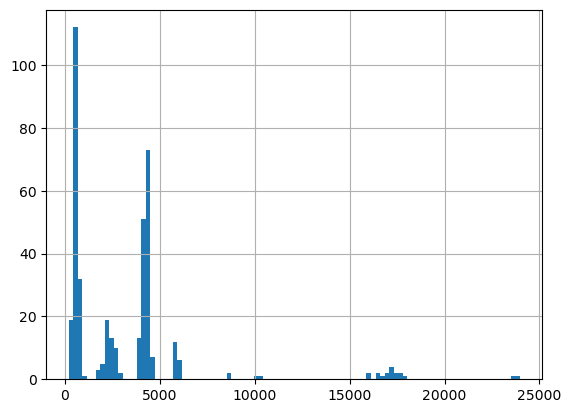

In [22]:
df_q_n.n.hist(bins = 100)

In [31]:
df_policy.query('dealer == 2 and usable_ace == 1').sort_values('player_sum')

,dealer,player_sum,usable_ace,action
185,2,12,1,stick
119,2,13,1,hit
187,2,14,1,hit
154,2,15,1,stick
163,2,16,1,stick
172,2,17,1,stick
136,2,18,1,stick
125,2,19,1,stick
115,2,20,1,stick
140,2,21,1,stick


In [47]:
df_q.query("player_sum == 17 and usable_ace == 1").sort_values(['dealer','q_value'])

,dealer,player_sum,usable_ace,action,q_value
268,1,17,1,hit,-0.599327
274,1,17,1,stick,-0.582181
208,2,17,1,hit,-0.221338
366,2,17,1,stick,-0.105354
236,3,17,1,hit,-0.229642
360,3,17,1,stick,-0.041186
329,4,17,1,hit,-0.197952
377,4,17,1,stick,-0.016667
333,5,17,1,hit,-0.103203
239,5,17,1,stick,-0.013115
